# Photonic Band Gap in Disordered media

***

`Tostada.meep_geometry` allows conversion of a phase-/point-distribution to a MEEP geometrical object. This geometrical object can be combined with other objects to do a full optical simulation with MPI parallelized meep installation within tostada. In this notebook, we will
1) Convert a `tostada.PointDistribution` to `meep.geometry` object and use it to study photonic band gap in stealthy disordered media.
2) First, convert a `tostada.PointDistribution` to `tostada.PhaseDistribution` and then convert it to `meep.geometry` object and verify the results of **(1)**.

***

### 1) `PointDistribution` to `meep.geometry`

In [ ]:
import numpy as np
import meep as mp
import tostada as tost
import matplotlib.pyplot as plt

In [ ]:
process = tost.Pointprocess(7,0.26,0.5)
points = process.RandomSequentialAdsorption()

Estimated particles to be deposited=196 with mean inter-particle distance=0.5


number of experiments:2536700): |------------------------------| 2.5% Current FF=3.980 of 4.000


### We shall use this to create stealthy configuration using `tostada.Optimization`. 

In [ ]:
opt = tost.Optimization(points)
opt_xy = opt.optimize(points.Q_from_chi(0.5))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          392     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.68404D-02    |proj g|=  9.77242D-02

At iterate    1    f=  2.66662D-02    |proj g|=  2.65008D-02

At iterate    2    f=  1.46534D-02    |proj g|=  1.13734D-02

At iterate    3    f=  8.09299D-03    |proj g|=  5.25737D-03

At iterate    4    f=  4.12408D-03    |proj g|=  2.65093D-03

At iterate    5    f=  2.26076D-03    |proj g|=  1.33713D-03

At iterate    6    f=  1.41442D-03    |proj g|=  9.78930D-04

At iterate    7    f=  1.00618D-03    |proj g|=  5.79110D-04

At iterate    8    f=  7.63331D-04    |proj g|=  4.70051D-04

At iterate    9    f=  5.72808D-04    |proj g|=  3.31182D-04

At iterate   10    f=  4.44861D-04    |proj g|=  2.41943D-04

At iterate   11    f=  3.53352D-04    |proj g|=  2.29565D-04

At iterate   12    f=  2.77393D-04    |proj g|=  2.18735D-04

At iterate   13    f=  2.2

In [ ]:
points_opt = tost.PointDistribution(positions=opt.opt_positions,diameter=points.diameter,BoxSize=points.BoxSize)

<Axes: title={'center': 'Point Distribution, mean interparticle distance = 0.5'}, xlabel='X ($\\mu$m)', ylabel='Y ($\\mu$m)'>

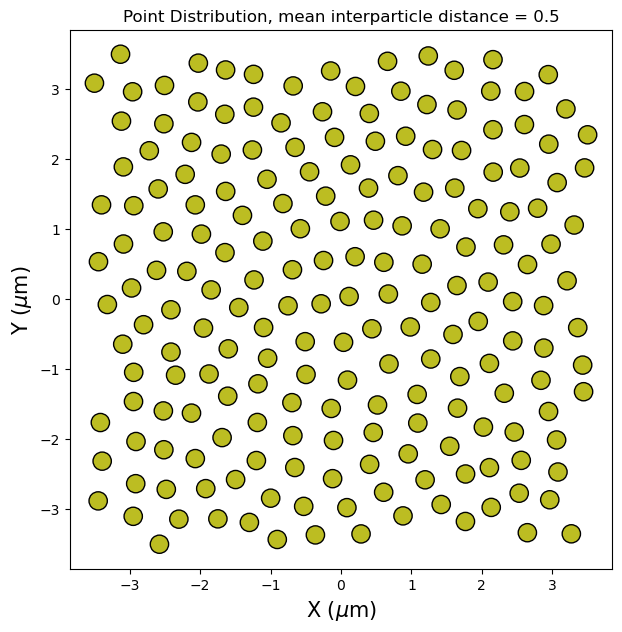

In [ ]:
fig = tost.Visualize(points_opt)
fig.plot_distribution()

#### The disks visualized above can be converted to meep geometry from `meep_geometry` in `tostada.physics`. The details of the material properties can be specified using `tostada.util.materials`.

In [ ]:
from tostada.physics import meep_geometry as tmp

While `Meep_geometry` class can create 2D or 3D geometries, here, we shall simulate a 2D system (disks -> infinitely long cylinders) for quick simulations. 

**For 3D simulations, it is recommended to use the regular `.py` file and exploit the parallelization from MPI meep by activating `tost` environment and running:**

##### _mpirun -np 4 python <script_name>.py_

where 4 is the number of processes. A general rule of thumb is to keep it less than half of the total number of cores on the machine to avoid gridlock.

In [ ]:
tostgeom = tmp.Meep_geometry(points_opt, #pointdistribution obtained from the optimization
                             tost.Material(name='eg',refractive_index=3)
                             )
geom = tostgeom.create_meep_geometry(object_shape='cylinder') #cylinders

This creates a list of `tostada.totalparticles` geometrical object. This can be test using:

In [9]:
print (geom[0].radius, geom[0].height)

0.13 1e+20


Now, let us create a `meep.Simulation` object. We choose a wavelength range of $\lambda= [1 - 2.5]\mu m$. To study formation of band-gap, we use Local Density of States (LDOS). Essentially, it measures power radiated by a unit dipole current in its surroundings thereby measuring how much the harmonic modes of a given system overlap with the source point. Here, we place such a current in the middle of the simulation domain.

In [ ]:
f_min = 1/2.5 #smallest frequency
f_max = 1/1 #largest frequency
f_cen = (f_min+f_max)/2 #central frequency
nfreqs = 100 #number of samples between f_min and f_max
df = f_max - f_min 

sim = mp.Simulation(cell_size=mp.Vector3(points.Lx+2.6,points.Ly+2.6), #size of the simulation domain
                    resolution=1/0.01, #pixels per micron 
                    geometry = geom, #geometry created from tostada
                    sources = [mp.Source(mp.GaussianSource(frequency=f_cen,width=df), #source to excite the simulation. Here, we use a point-source
                                        component=mp.Ez, center=mp.Vector3(0,0))],
                    boundary_layers=[mp.PML(1)], #perfectly-matched-layer for the boundaries
                    dimensions=2
                                        )

The geometry of the simulation can be plotted using:

     cylinder, center = (0.11432,0.039207,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-1.60022,-0.708704,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-2.51468,-2.15043,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (2.02067,-1.8268,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-2.41427,-0.150883,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-1.60783,-1.3851,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-1.98182,0.930188,0)
          radius 0.13, hei

<Axes: xlabel='X', ylabel='Y'>

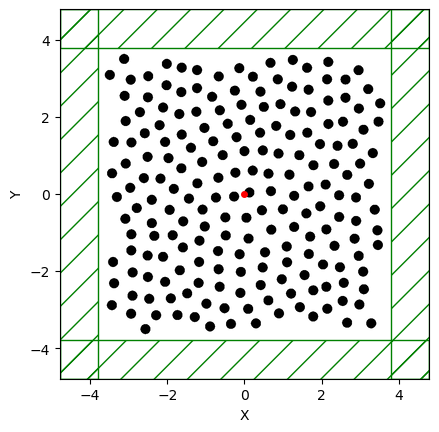

In [28]:
sim.plot2D()

We can now run the simulation and collect the LDOS results.

In [29]:
sim.run(mp.dft_ldos(f_cen,df,nfreqs),
            until_after_sources=mp.stop_when_fields_decayed(20,
                                                            mp.Ez,
                                                            mp.Vector3(),
                                                            1e-3))
ldos_data = sim.ldos_data
freqs = np.linspace(f_min, f_max, nfreqs)

-----------
Initializing structure...
time for choose_chunkdivision = 0.00458193 s
Working in 2D dimensions.
Computational cell is 9.57 x 9.58 x 0 with resolution 100
     cylinder, center = (0.11432,0.039207,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-1.60022,-0.708704,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-2.51468,-2.15043,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (2.02067,-1.8268,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-2.41427,-0.150883,0)
          radius 0.13, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (9,9,9)
     cylinder, center = (-1.60783,-1.3851,0)
          radi

We must normalize this data with a simulation where there are no objects; just vacuum. For this, one can simply specify, `geometry=[]` as meep then assumes vacuum.

In [ ]:
sim.reset_meep() # resets any previously stored quantities.

sim = mp.Simulation(cell_size=mp.Vector3(points.Lx+2.6,points.Ly+2.6),
                    resolution=1/0.01, #pixels per micron
                    geometry = [],
                    sources = [mp.Source(mp.GaussianSource(frequency=f_cen,width=df),
                                        component=mp.Ez, center=mp.Vector3())],
                    boundary_layers=[mp.PML(1)],
                    dimensions=2
                    )

sim.run(mp.dft_ldos(f_cen,df,nfreqs),
            until_after_sources=mp.stop_when_fields_decayed(20,
                                                            mp.Ez,
                                                            mp.Vector3(),
                                                            1e-4))
#ldos_data = mp.get_fluxes(ldos_monitor)
ldos_data_vac = sim.ldos_data


-----------
Initializing structure...
time for choose_chunkdivision = 0.00145316 s
Working in 2D dimensions.
Computational cell is 9.57 x 9.58 x 0 with resolution 100
time for set_epsilon = 1.08268 s
-----------
on time step 889 (time=4.445), 0.00450108 s/step
on time step 1799 (time=8.995), 0.00439776 s/step
on time step 2710 (time=13.55), 0.00439218 s/step
on time step 3621 (time=18.105), 0.00439359 s/step
field decay(t = 20.005): 13.773081930143427 / 13.773081930143427 = 1.0
on time step 4532 (time=22.66), 0.00439292 s/step
on time step 5443 (time=27.215), 0.00439111 s/step
on time step 6353 (time=31.765), 0.00439782 s/step
on time step 7265 (time=36.325), 0.00438991 s/step
field decay(t = 40.005): 1.0661093685653108e-11 / 13.773081930143427 = 7.740528764531998e-13
ldos0:, 0.39999999999999997, 0.40002896295813717
ldos0:, 0.406060606060606, 0.40609091512324785
ldos0:, 0.4121212121212121, 0.41215289612536204
ldos0:, 0.41818181818181815, 0.41821490476814627
ldos0:, 0.4242424242424242, 

Let's plot the results

Text(0, 0.5, 'Local Density of States')

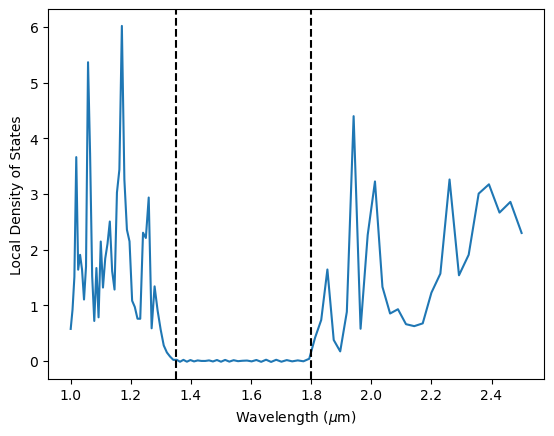

In [32]:
ldos_sim = np.asarray(ldos_data)
ldos_vac = np.asarray(ldos_data_vac)

plt.plot(1/freqs,ldos_sim/ldos_vac)
plt.axvline(x=1.35,linestyle='--',color='black')
plt.axvline(x=1.8,linestyle='--',color='black')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Local Density of States')

It can be clearly seen that there exists no states (LDOS = 0) for a wavelength range of $\lambda=[1.35 - 1.8]\mu m$ thereby indicating presence of a band-gap. This can be further verified by launching a plane-wave in the xy-plane and measuring transmittance from it but this will lie beyond the scope of this demonstration.

***

### 2) `PointDistribution` to `PhaseDistribution` to `meep.geometry`

The point distribution obtained above can be converted to a phase distribution using `Phaseobject()` method. The idea now is to verify if directly exporting a phase distribution can yield the exact same LDOS results. 
**But note that this will replace the disks with pores. To obtain objects of the same size, we can invert the phases using `invert_phases()` method in `PhaseDistribution`.**

In [ ]:
Phase = points_opt.Phaseobject(dx=0.01) # remember to keep this same as the meep simulation for consistency
Phase.image = np.logical_not(Phase.image) # phase inversion

Now, the same method can be used that was used earlier as the distribution automatically gets identified within the class. Essentially, tostada now interpolates the phase distribution to permittivity values of _medium A_ and _medium B_ using `meep.MaterialGrid()`. Here, _medium A_ is vacuum and _Medium B_ is refractive index = 3.

In [ ]:
tostgeom = tmp.Meep_geometry(Phase,tost.Material(name='eg',refractive_index=3))

geom = tostgeom.create_meep_geometry()  # Now uses PhaseDistribution

     block, center = (0,0,0)
          size (7,7,0)
          axes (1,0,0), (0,1,0), (0,0,1)


<Axes: xlabel='X', ylabel='Y'>

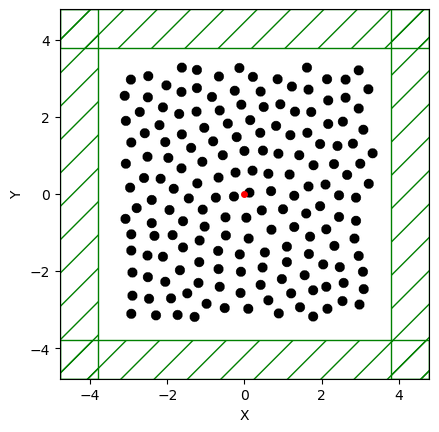

In [ ]:
sim.reset_meep() # resetting from previous runs

# same simulation parameters as before

sim = mp.Simulation(cell_size=mp.Vector3(points.Lx+2.6,points.Ly+2.6),
                    resolution=1/0.01, #pixels per micron
                    geometry = geom,
                    sources = [mp.Source(mp.GaussianSource(frequency=f_cen,width=df),
                                        component=mp.Ez, center=mp.Vector3(0,0))],
                    boundary_layers=[mp.PML(1)],
                    dimensions=2
                                        )
sim.plot2D()

The simulation geometry is identical to what was obtained with the PointDistribution.

In [44]:
sim.run(mp.dft_ldos(f_cen,df,nfreqs),
            until_after_sources=mp.stop_when_fields_decayed(20,
                                                            mp.Ez,
                                                            mp.Vector3(),
                                                            1e-3))
ldos_data = sim.ldos_data
freqs = np.linspace(f_min, f_max, nfreqs)

sim.reset_meep()

sim = mp.Simulation(cell_size=mp.Vector3(points.Lx+2.6,points.Ly+2.6),
                    resolution=1/0.01, #pixels per micron
                    geometry = [],
                    sources = [mp.Source(mp.GaussianSource(frequency=f_cen,width=df),
                                        component=mp.Ez, center=mp.Vector3())],
                    boundary_layers=[mp.PML(1)],
                    dimensions=2
                    )

sim.run(mp.dft_ldos(f_cen,df,nfreqs),
            until_after_sources=mp.stop_when_fields_decayed(20,
                                                            mp.Ez,
                                                            mp.Vector3(),
                                                            1e-4))
#ldos_data = mp.get_fluxes(ldos_monitor)
ldos_data_vac = sim.ldos_data


-----------
Initializing structure...
time for choose_chunkdivision = 0.000701189 s
Working in 2D dimensions.
Computational cell is 9.57 x 9.58 x 0 with resolution 100
     block, center = (0,0,0)
          size (7,7,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 2.09207 s
-----------
on time step 855 (time=4.275), 0.00467855 s/step
on time step 1728 (time=8.64), 0.00458707 s/step
on time step 2604 (time=13.02), 0.0045685 s/step
on time step 3480 (time=17.4), 0.00457087 s/step
field decay(t = 20.005): 10.923774309999416 / 10.923774309999416 = 1.0
on time step 4355 (time=21.775), 0.00457478 s/step
on time step 5230 (time=26.15), 0.00457161 s/step
on time step 6107 (time=30.535), 0.00456182 s/step
on time step 6982 (time=34.91), 0.00457568 s/step
on time step 7859 (time=39.295), 0.00456513 s/step
field decay(t = 40.005): 0.29515059454358095 / 10.923774309999416 = 0.02701910403562674
on time step 8736 (time=43.68), 0.00456524 s/step
on time step 9609 (time=48.045), 0.0

field decay(t = 200.035): 0.007374056384310291 / 10.923774309999416 = 0.0006750465704477454
ldos0:, 0.39999999999999997, 0.9084460665590496
ldos0:, 0.406060606060606, 1.047479620104912
ldos0:, 0.4121212121212121, 0.9632387313139754
ldos0:, 0.41818181818181815, 0.7440936852704928
ldos0:, 0.4242424242424242, 1.1397112638645417
ldos0:, 0.4303030303030303, 1.4928414979009321
ldos0:, 0.43636363636363634, 1.8153244097311478
ldos0:, 0.4424242424242424, 0.540548410078948
ldos0:, 0.4484848484848485, 0.6476281033382605
ldos0:, 0.45454545454545453, 0.3925322606012328
ldos0:, 0.4606060606060606, 0.7379633135429764
ldos0:, 0.4666666666666667, 0.43918276471466255
ldos0:, 0.4727272727272727, 0.2452724327295764
ldos0:, 0.47878787878787876, 0.3306497256274801
ldos0:, 0.48484848484848486, 0.43194956850360827
ldos0:, 0.4909090909090909, 0.3225155179299676
ldos0:, 0.49696969696969695, 1.6202458958058263
ldos0:, 0.503030303030303, 1.1977241007014652
ldos0:, 0.509090909090909, 0.3569234552226612
ldos0:, 0.5

Text(0, 0.5, 'Local Density of States')

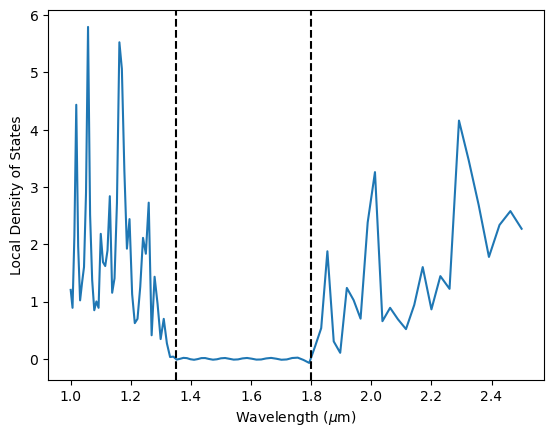

In [45]:
ldos_sim = np.asarray(ldos_data)
ldos_vac = np.asarray(ldos_data_vac)

plt.plot(1/freqs,ldos_sim/ldos_vac)
plt.axvline(x=1.35,linestyle='--',color='black')
plt.axvline(x=1.8,linestyle='--',color='black')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Local Density of States')

Clearly, the results are the same from both the methods and one can use them interchangeably for trivial cases like infinite cylinders (2D) or spheres (in 3D). 